# Data Preprocessing & Feature Engineering — Practice Notebook
## Topic: Missing Values, Outliers & Encoding

Welcome! This notebook gives you hands-on practice with the three core
cleaning skills:

1. **Handling missing values** (imputation)
2. **Detecting & removing outliers** (IQR method)
3. **Encoding categorical variables** (Label & One-Hot)

## Step 0 — Setup & the messy dataset *(provided — just run this cell)*

We work with a small employee dataset (20 rows) that was deliberately built
to contain every problem we study: missing values, an impossible age (150),
a huge salary outlier (9,999,999), an ordinal column (Education) and several
nominal columns (Gender, Department, City).

In [3]:
import pandas as pd
import numpy as np

data = {
    'EmployeeID': list(range(1, 21)),
    'Age':        [25,30,np.nan,35,28,150,40,33,29,45,38,26,50,31,27,np.nan,42,36,34,39],
    'Gender':     ['Male','Female','Male','Female','Male','Female',np.nan,'Male','Female','Male',
                   'Female','Male','Female','Male','Female','Male','Female','Male','Female','Male'],
    'Department': ['Sales','IT','HR','Finance','IT','Sales','HR','Finance','IT','Sales',
                   np.nan,'IT','Finance','HR','Sales','IT','Finance','Sales','HR','IT'],
    'Education':  ['Bachelor','Master','Bachelor','PhD','Bachelor','High School','Master','Bachelor',
                   'Master','High School','PhD','Bachelor','Master','Bachelor','High School','Master',
                   'PhD','Bachelor','Master','Bachelor'],
    'Experience': [2,5,3,10,4,1,12,8,5,np.nan,15,3,20,np.nan,2,7,18,9,11,np.nan],
    'Salary':     [45000,60000,50000,90000,np.nan,35000,75000,65000,58000,48000,
                   95000,9999999,110000,np.nan,38000,70000,105000,62000,72000,68000],
    'City':       ['Mumbai','Delhi','Mumbai','Bangalore','Delhi','Pune','Mumbai','Bangalore','Delhi',
                   'Pune','Mumbai','Delhi','Bangalore','Pune','Mumbai','Delhi','Bangalore','Pune',
                   'Mumbai','Delhi'],
}
df = pd.DataFrame(data)
print("Shape:", df.shape)
df.head()

Shape: (20, 8)


,EmployeeID,Age,Gender,Department,Education,Experience,Salary,City
0,1,25.0,Male,Sales,Bachelor,2.0,45000.0,Mumbai
1,2,30.0,Female,IT,Master,5.0,60000.0,Delhi
2,3,NaN,Male,HR,Bachelor,3.0,50000.0,Mumbai
3,4,35.0,Female,Finance,PhD,10.0,90000.0,Bangalore
4,5,28.0,Male,IT,Bachelor,4.0,NaN,Delhi


# Part 1 — Handling Missing Values

### Q1. Inspect the data
Display the first 5 rows, then use `.info()` to see the column types and how many non-null values each column has.

In [4]:
df.head()

,EmployeeID,Age,Gender,Department,Education,Experience,Salary,City
0,1,25.0,Male,Sales,Bachelor,2.0,45000.0,Mumbai
1,2,30.0,Female,IT,Master,5.0,60000.0,Delhi
2,3,NaN,Male,HR,Bachelor,3.0,50000.0,Mumbai
3,4,35.0,Female,Finance,PhD,10.0,90000.0,Bangalore
4,5,28.0,Male,IT,Bachelor,4.0,NaN,Delhi


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmployeeID  20 non-null     int64  
 1   Age         18 non-null     float64
 2   Gender      19 non-null     object 
 3   Department  19 non-null     object 
 4   Education   20 non-null     object 
 5   Experience  17 non-null     float64
 6   Salary      18 non-null     float64
 7   City        20 non-null     object 
dtypes: float64(3), int64(1), object(4)
memory usage: 1.4+ KB


### Q2. Count missing values
Count how many values are missing in **each** column.

In [6]:
df.isnull().sum()

EmployeeID    0
Age           2
Gender        1
Department    1
Education     0
Experience    3
Salary        2
City          0
dtype: int64

### Q3. Percentage missing
Show the **percentage** of values missing in each column, rounded to 1 decimal place.

In [7]:
(df.isnull().mean() * 100).round(1)

EmployeeID     0.0
Age           10.0
Gender         5.0
Department     5.0
Education      0.0
Experience    15.0
Salary        10.0
City           0.0
dtype: float64

### Q4. Which column has the most missing values?
Answer in the markdown cell, then prove it with one line of code.

Column "Experience" has the most Missing Values

In [8]:
df.isnull().mean().max()

0.15

### Q5. Impute `Age` with the median
Fill the missing ages with the column **median** (median is safer than mean because Age has the outlier 150).

In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [10]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        1
Department    1
Education     0
Experience    3
Salary        2
City          0
dtype: int64

### Q6. Impute `Experience` with the median

In [11]:
df["Experience"] = df["Experience"].fillna(df["Experience"].median())

In [12]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        1
Department    1
Education     0
Experience    0
Salary        2
City          0
dtype: int64

### Q7. Impute `Salary` with the median

In [13]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

In [14]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        1
Department    1
Education     0
Experience    0
Salary        0
City          0
dtype: int64

### Q8. Impute `Gender` with the mode
`Gender` is categorical (text), so fill it with the **most frequent** value.

In [15]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [16]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        0
Department    1
Education     0
Experience    0
Salary        0
City          0
dtype: int64

### Q9. Impute `Department` with the mode

In [17]:
df["Department"] = df["Department"].fillna(df["Department"].mode()[0])

In [18]:
df.isnull().sum()

EmployeeID    0
Age           0
Gender        0
Department    0
Education     0
Experience    0
Salary        0
City          0
dtype: int64

### Q10. Verify no missing values remain
Confirm the total number of missing values across the whole DataFrame is now **0**.

In [19]:
print(df.isnull().sum().sum())

0


# Part 2 — Detecting & Removing Outliers (IQR)

### Q11. Quartiles & IQR for `Age`
Compute `Q1` (25th percentile), `Q3` (75th percentile) and `IQR = Q3 - Q1` for the `Age` column. Print all three.

In [20]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

print(Q1)
print(Q3)
print(IQR)

29.75
39.25
9.5


### Q12. Lower & upper bounds for `Age`
Using the IQR rule, compute the lower and upper 'fences':

$$\text{lower}=Q1-1.5\times IQR \qquad \text{upper}=Q3+1.5\times IQR$$

In [21]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(lower_fence)
print(upper_fence)

15.5
53.5


### Q13. Find the outlier rows in `Age`
Show the rows where `Age` is below the lower bound or above the upper bound.

In [23]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)



Lower Bound: 15.5
Upper Bound: 53.5


In [24]:
age_outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
age_outliers

,EmployeeID,Age,Gender,Department,Education,Experience,Salary,City
5,6,150.0,Female,Sales,High School,1.0,35000.0,Pune


### Q14. Repeat for `Salary`
Compute Q1, Q3, IQR, the bounds, and show the outlier rows for the `Salary` column.

In [25]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Lower Bound: 21875.0
Upper Bound: 112875.0


### Q15. Remove the outliers
Keep only the rows where **both** `Age` and `Salary` fall inside their IQR bounds. Print the shape before and after.

In [26]:
print("Shape before:", df.shape)

# ----- Age IQR -----
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

age_lower = Q1_age - 1.5 * IQR_age
age_upper = Q3_age + 1.5 * IQR_age

# ----- Salary IQR -----
Q1_salary = df['Salary'].quantile(0.25)
Q3_salary = df['Salary'].quantile(0.75)
IQR_salary = Q3_salary - Q1_salary

salary_lower = Q1_salary - 1.5 * IQR_salary
salary_upper = Q3_salary + 1.5 * IQR_salary

# Keep only rows where both Age and Salary are within bounds
df_clean = df[
    (df['Age'] >= age_lower) & (df['Age'] <= age_upper) &
    (df['Salary'] >= salary_lower) & (df['Salary'] <= salary_upper)
]

print("Shape after:", df_clean.shape)
print(df_clean)

Shape before: (20, 8)
Shape after: (18, 8)
    EmployeeID   Age  Gender Department    Education  Experience    Salary  \
0            1  25.0    Male      Sales     Bachelor         2.0   45000.0   
1            2  30.0  Female         IT       Master         5.0   60000.0   
2            3  34.5    Male         HR     Bachelor         3.0   50000.0   
3            4  35.0  Female    Finance          PhD        10.0   90000.0   
4            5  28.0    Male         IT     Bachelor         4.0   66500.0   
6            7  40.0    Male         HR       Master        12.0   75000.0   
7            8  33.0    Male    Finance     Bachelor         8.0   65000.0   
8            9  29.0  Female         IT       Master         5.0   58000.0   
9           10  45.0    Male      Sales  High School         7.0   48000.0   
10          11  38.0  Female         IT          PhD        15.0   95000.0   
12          13  50.0  Female    Finance       Master        20.0  110000.0   
13          14  31.0 

### Q16. *(Optional)* Visualise with a box plot
Draw a box plot of `Age` to see that the extreme value is gone. (Requires `matplotlib`.)

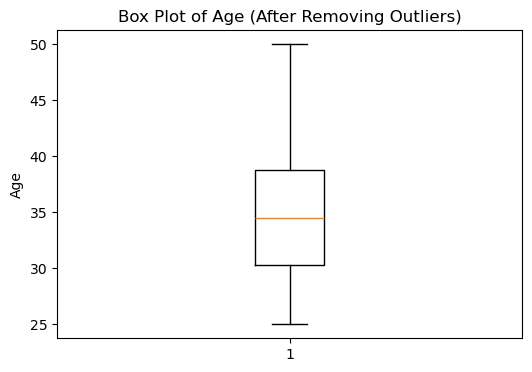

In [27]:
import matplotlib.pyplot as plt

# Box plot of Age after removing outliers
plt.figure(figsize=(6, 4))
plt.boxplot(df_clean['Age'].dropna(), vert=True)

plt.title("Box Plot of Age (After Removing Outliers)")
plt.ylabel("Age")

plt.show()

# Part 3 — Encoding Categorical Variables

### Q17. Label-encode `Education` (ordinal)
`Education` has a natural order: High School < Bachelor < Master < PhD. Create a new column `Education_Label` mapping these to 0, 1, 2, 3.

In [28]:
education_mapping = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}

df['Education_Label'] = df['Education'].map(education_mapping)
print(df[['Education', 'Education_Label']])

      Education  Education_Label
0      Bachelor                1
1        Master                2
2      Bachelor                1
3           PhD                3
4      Bachelor                1
5   High School                0
6        Master                2
7      Bachelor                1
8        Master                2
9   High School                0
10          PhD                3
11     Bachelor                1
12       Master                2
13     Bachelor                1
14  High School                0
15       Master                2
16          PhD                3
17     Bachelor                1
18       Master                2
19     Bachelor                1


### Q18. Encode `Gender` as 0/1
`Gender` has only two values, so map Male -> 0 and Female -> 1 into a new column `Gender_Label`.

In [29]:
# Define the mapping
gender_mapping = {
    'Male': 0,
    'Female': 1
}

# Create a new column
df['Gender_Label'] = df['Gender'].map(gender_mapping)

# Display the result
print(df[['Gender', 'Gender_Label']])

    Gender  Gender_Label
0     Male             0
1   Female             1
2     Male             0
3   Female             1
4     Male             0
5   Female             1
6     Male             0
7     Male             0
8   Female             1
9     Male             0
10  Female             1
11    Male             0
12  Female             1
13    Male             0
14  Female             1
15    Male             0
16  Female             1
17    Male             0
18  Female             1
19    Male             0


### Q19. One-hot encode `Department` and `City`
These are **nominal** (no order), so use one-hot encoding. Use `pd.get_dummies` with prefixes `Dept` and `City`.

In [30]:
# One-hot encode with integer values
df_encoded = pd.get_dummies(
    df,
    columns=['Department', 'City'],
    prefix=['Dept', 'City'],
    dtype=int
)

print(df_encoded.head())

   EmployeeID   Age  Gender Education  Experience   Salary  Education_Label  \
0           1  25.0    Male  Bachelor         2.0  45000.0                1   
1           2  30.0  Female    Master         5.0  60000.0                2   
2           3  34.5    Male  Bachelor         3.0  50000.0                1   
3           4  35.0  Female       PhD        10.0  90000.0                3   
4           5  28.0    Male  Bachelor         4.0  66500.0                1   

   Gender_Label  Dept_Finance  Dept_HR  Dept_IT  Dept_Sales  City_Bangalore  \
0             0             0        0        0           1               0   
1             1             0        0        1           0               0   
2             0             0        1        0           0               0   
3             1             1        0        0           0               1   
4             0             0        0        1           0               0   

   City_Delhi  City_Mumbai  City_Pune  
0         

### Q20. Inspect the final dataset
Print the final shape and the list of columns. Confirm there are no missing values.

In [31]:
# Print final shape
print("Final Shape:", df_encoded.shape)

# Print all column names
print("\nColumns:")
print(df_encoded.columns.tolist())

# Check for missing values
print("\nMissing Values in Each Column:")
print(df_encoded.isnull().sum())

# Confirm if there are any missing values
if df_encoded.isnull().sum().sum() == 0:
    print("\n✅ There are no missing values in the dataset.")
else:
    print("\n❌ Missing values still exist in the dataset.")

Final Shape: (20, 16)

Columns:
['EmployeeID', 'Age', 'Gender', 'Education', 'Experience', 'Salary', 'Education_Label', 'Gender_Label', 'Dept_Finance', 'Dept_HR', 'Dept_IT', 'Dept_Sales', 'City_Bangalore', 'City_Delhi', 'City_Mumbai', 'City_Pune']

Missing Values in Each Column:
EmployeeID         0
Age                0
Gender             0
Education          0
Experience         0
Salary             0
Education_Label    0
Gender_Label       0
Dept_Finance       0
Dept_HR            0
Dept_IT            0
Dept_Sales         0
City_Bangalore     0
City_Delhi         0
City_Mumbai        0
City_Pune          0
dtype: int64

✅ There are no missing values in the dataset.


# Bonus Challenge

### Q21. Write a single `preprocess(df)` function
Combine everything into one reusable function that takes a raw DataFrame and returns the cleaned, encoded version. Test it by re-creating the raw data and passing it in.

In [32]:
import pandas as pd
import numpy as np

def preprocess(df):
    # Create a copy to avoid modifying the original DataFrame
    df = df.copy()
 
    # 1. Handle Missing Values
    
    for col in ['Age', 'Experience', 'Salary']:
        df[col] = df[col].fillna(df[col].median())

    for col in ['Gender', 'Department']:
        df[col] = df[col].fillna(df[col].mode()[0])

     
    # 2. Remove Outliers (IQR)
     
    mask = pd.Series(True, index=df.index)

    for col in ['Age', 'Salary']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask &= df[col].between(lower, upper)

    df = df[mask].reset_index(drop=True)

     
    # 3. Label Encoding
    
    edu_order = {
        'High School': 0,
        'Bachelor': 1,
        'Master': 2,
        'PhD': 3
    }

    df['Education_Label'] = df['Education'].map(edu_order)

    df['Gender_Label'] = df['Gender'].map({
        'Male': 0,
        'Female': 1
    })

    
    # 4. One-Hot Encoding
    
    df = pd.get_dummies(
        df,
        columns=['Department', 'City'],
        prefix=['Dept', 'City']
    )

 
    # 5. Convert True/False to 0/1
  
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    return df

In [33]:
# Re-create the raw dataset
df_raw = pd.DataFrame(data)

# Apply preprocessing
df_clean = preprocess(df_raw)

# Display results
print("Shape:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())

print("\nMissing Values:")
print(df_clean.isnull().sum().sum())

print("\nFirst 5 Rows:")
print(df_clean.head())

Shape: (18, 16)

Columns:
['EmployeeID', 'Age', 'Gender', 'Education', 'Experience', 'Salary', 'Education_Label', 'Gender_Label', 'Dept_Finance', 'Dept_HR', 'Dept_IT', 'Dept_Sales', 'City_Bangalore', 'City_Delhi', 'City_Mumbai', 'City_Pune']

Missing Values:
0

First 5 Rows:
   EmployeeID   Age  Gender Education  Experience   Salary  Education_Label  \
0           1  25.0    Male  Bachelor         2.0  45000.0                1   
1           2  30.0  Female    Master         5.0  60000.0                2   
2           3  34.5    Male  Bachelor         3.0  50000.0                1   
3           4  35.0  Female       PhD        10.0  90000.0                3   
4           5  28.0    Male  Bachelor         4.0  66500.0                1   

   Gender_Label  Dept_Finance  Dept_HR  Dept_IT  Dept_Sales  City_Bangalore  \
0             0             0        0        0           1               0   
1             1             0        0        1           0               0   
2           